In [33]:
# 라이브러리 임포트
import numpy as np
import pandas as pd
from datetime import datetime

pd.set_option('display.max_columns', None)  # 모든 컬럼 다 보이게 설정

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats
from scipy.stats import shapiro

# 지리 라이브러리
from geopy.distance import geodesic

# 전처리용
from itertools import combinations

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 윈도우용 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')  # 말굿 고딕 (Windows 기본 한글 폰트)
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 머신러닝 - 전처리, 모델, 평가
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 머신러닝 알고리즘 (필요에 따라 선택적으로 추가)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier, XGBRegressor

# 텍스트 처리
from rapidfuzz import process, fuzz

# 경고 메시지 무시
import warnings
warnings.filterwarnings('ignore')

# # # 딥러닝 (선택사항)
# import tensorflow as tf
# from tensorflow import keras
# from keras.models import Sequential
# from keras.layers import Dense, Dropout

# 모델 해석
import shap



# dataset

In [217]:
from generate_dataset import simulate_corsia_mrv_fuel_burn, test_sum
df = simulate_corsia_mrv_fuel_burn()
df = df[df['year'] == 2019][['airline_id', 'operator_state', 'region', 'year','fuel_burn_tonnes']]
df

,airline_id,operator_state,region,year,fuel_burn_tonnes
0,AL0001,India,APAC,2019,1.669232e+06
7,AL0002,France,EUR,2019,2.904625e+05
14,AL0003,Brazil,LAM,2019,5.203632e+05
21,AL0004,"Korea, Rep.",APAC,2019,1.010770e+06
28,AL0005,United States,NAM,2019,8.916956e+04
...,...,...,...,...,...
4165,AL0596,China,APAC,2019,3.013853e+05
4172,AL0597,"Korea, Rep.",APAC,2019,1.139743e+05
4179,AL0598,Singapore,APAC,2019,3.401084e+05
4186,AL0599,Canada,NAM,2019,5.582960e+05


<Axes: xlabel='fuel_burn_tonnes', ylabel='Count'>

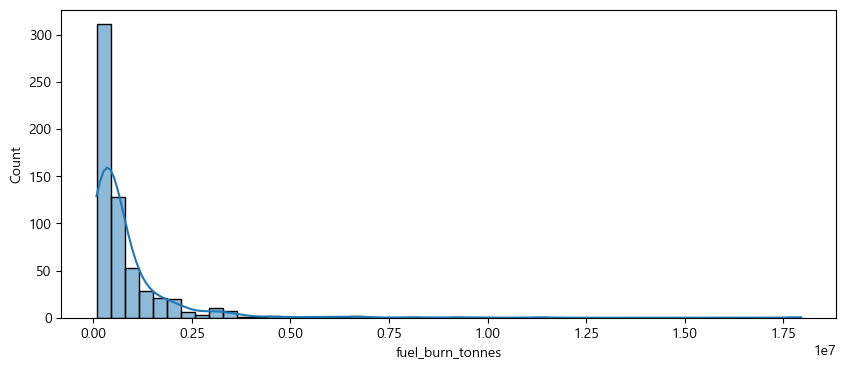

In [220]:
# 2019년 연도별 항공사 연료소모량 분포 시각화
plt.figure(figsize=(10,4))
# sns.histplot(df, x='fuel_burn_tonnes', bins=50, hue='region', kde=True, multiple='stack' )
# plt.yscale("log")
sns.histplot(df, x='fuel_burn_tonnes', bins=50, kde=True)
# 일부 대형 항공사와 소규모 항공사가 존재

# model

## emission Factor

$EF_i = (1 - s_i \lambda_i)\cdot EF_{fossil}$

In [ ]:
# Emission Factor
# assume fixed
# 향후 논문에서는 saf price, tech 발전 등을 반영한 동적 모형 고려 가능
ef_fossil = 3.16  # kg CO2 per kg fuel  ## base : 3.16 kg CO2 per kg fuel
## 배출계수
lambda_saf = 0.8  # kg CO2 per kg fuel  ## lambda saf:  life cycle reduction : 0.8 kg CO2 per kg fuel assumption
                  # 0.8 근거 필요 -> 0.80 EF
rate_saf = 0.02  # 2% SAF use from 2025   ## saf use: 2025 2% fixed assumption       # '30. 6% 
ef = (1 - rate_saf * lambda_saf ) * ef_fossil  # adjusted emission factor
print('effective emission factor:', ef)

effective emission factor: 3.10944


## economic growth

${FB}_{i,t}\ =\ {FB}_{i,0}\ \cdot\ \prod_{\tau=1}^{t}g_{i,\tau}\ ,\ \ g_{i,\tau}\ ~\ \mathcal{D}_i(\mu_i,\sigma_i^2)$

In [ ]:
# Define growth scenarios 
econominc_growth = {     # equal == aviation growth
    # "low"   : {"g_mean": 0.01, "g_sd": 0.03},
    "normal": {"g_mean": 0.03, "g_sd": 0.04},    # baseline 과거 3년? 평균 성장률
    # "high"  : {"g_mean": 0.05, "g_sd": 0.05}
    }

$C_{i,t}=P_t\cdot O_{i,t}\ \ ,\ \ \ \ \ \ \ \ \ P_t∼F(μ_p,σ_{p}^2)$

In [ ]:
# Define carbon price scenarios
carbon_price = {
    # "low": {"p_mean": 50, "p_sd": 15},
    "normal": {"p_mean": 80, "p_sd": 20},
    # "high": {"p_mean": 120, "p_sd": 30}
    }


## Carbon Offset and Offset cost
$O_{i,t}=max(E_{i,t}-{\overline{E}}_i , 0 )$

In [126]:
# define offset dataset
df_offset = df.copy()
df_offset.columns = ['airline_id', 'operator_state', 'region', 'year','offset']
df_offset

,airline_id,operator_state,region,year,offset
0,AL0001,India,APAC,2019,1.669232e+06
7,AL0002,France,EUR,2019,2.904625e+05
14,AL0003,Brazil,LAM,2019,5.203632e+05
21,AL0004,"Korea, Rep.",APAC,2019,1.010770e+06
28,AL0005,United States,NAM,2019,8.916956e+04
...,...,...,...,...,...
4165,AL0596,China,APAC,2019,3.013853e+05
4172,AL0597,"Korea, Rep.",APAC,2019,1.139743e+05
4179,AL0598,Singapore,APAC,2019,3.401084e+05
4186,AL0599,Canada,NAM,2019,5.582960e+05


In [128]:
# scenario dictionary
scenarios = {
    "economic_growth": economic_growth,
    "carbon_price": carbon_price
    }
scenarios

{'economic_growth': {'low': {'g_mean': 0.01, 'g_sd': 0.03},
  'normal': {'g_mean': 0.03, 'g_sd': 0.04},
  'high': {'g_mean': 0.05, 'g_sd': 0.05}},
 'carbon_price': {'low': {'p_mean': 50, 'p_sd': 15},
  'normal': {'p_mean': 80, 'p_sd': 20},
  'high': {'p_mean': 120, 'p_sd': 30}}}

# 몬테카를로 시뮬레이션

In [139]:
import numpy as np
import pandas as pd


def sample_lognormal_from_mean_sd(rng, mean, sd, size):
    # P ~ LogNormal(mu, sigma)에서 (E[P]=mean, SD[P]=sd)가 되도록 mu,sigma 변환
    var = sd**2
    sigma2 = np.log(1 + var/(mean**2))
    sigma = np.sqrt(sigma2)
    mu = np.log(mean) - 0.5*sigma2
    return rng.lognormal(mean=mu, sigma=sigma, size=size)

def one_run_costs(
    df_2019,                 # columns: airline_id, operator_state, fuel_burn_tonnes (2019)
    econ_params,             # {"g_mean":..., "g_sd":...}
    carbon_params,           # {"p_mean":..., "p_sd":...}
    years=range(2020, 2050), # 시뮬레이션 기간
    baseline_year=2019,
    seed=0,
    O_rule="zero_baseline",  # "zero_baseline" or "growth_neutral"
):
    rng = np.random.default_rng(seed)

    airlines = df_2019["airline_id"].to_numpy()
    fuel0 = df_2019["fuel_burn_tonnes"].to_numpy()

    # 항공사별 성장률 샘플링
    g_i = rng.normal(econ_params["g_mean"], econ_params["g_sd"], size=len(df_2019))
    g_i = np.clip(g_i, -0.10, 0.20)

    # 연도별 탄소가격 샘플링 (lognormal)
    P_t = sample_lognormal_from_mean_sd(
        rng,
        mean=carbon_params["p_mean"],
        sd=carbon_params["p_sd"],
        size=len(list(years))
    )

    out_rows = []
    for k, y in enumerate(years):
        t = y - baseline_year

        # 연료소모 (단순 성장)
        fuel_t = fuel0 * ((1 + g_i) ** t)

        # CO2 배출
        E_t = fuel_t * ef

        # 상쇄 의무 O
        if O_rule == "zero_baseline":
            O_t = E_t  # 베이스라인 0 가정
        elif O_rule == "growth_neutral":
            # 성장중립(2019 기준 초과분만)
            E0 = fuel0 * ef
            O_t = np.maximum(E_t - E0, 0.0)
        else:
            raise ValueError("Unknown O_rule")

        # 비용
        C_t = P_t[k] * O_t

        out_rows.append(pd.DataFrame({
            "airline_id": airlines,
            "year": y,
            "P_t": P_t[k],
            "O_t": O_t,
            "C_t": C_t
        }))

    return pd.concat(out_rows, ignore_index=True)


In [140]:
def monte_carlo(
    df_2019,
    econ_key="normal",
    carbon_key="normal",
    years=range(2020, 2050),
    n_sims=1000,
    seed=42,
    O_rule="growth_neutral"
):
    econ_params = economic_growth[econ_key]
    carbon_params = carbon_price[carbon_key]

    rng = np.random.default_rng(seed)
    sim_seeds = rng.integers(0, 2**32 - 1, size=n_sims)

    summary = []
    for s, sd in enumerate(sim_seeds, start=1):
        sim_df = one_run_costs(
            df_2019=df_2019,
            econ_params=econ_params,
            carbon_params=carbon_params,
            years=years,
            seed=int(sd),
            O_rule=O_rule
        )

        # 예: 연도별 총비용
        tot = sim_df.groupby("year")["C_t"].sum().reset_index()
        tot["sim"] = s
        summary.append(tot)

    return pd.concat(summary, ignore_index=True)


In [141]:
mc = monte_carlo(df_2019=df, econ_key="normal", carbon_key="high", n_sims=500)
mc.head()


,year,C_t,sim
0,2020,5.495421e+09,1
1,2021,1.246000e+10,1
2,2022,1.799380e+10,1
3,2023,4.323582e+10,1
4,2024,4.388600e+10,1


In [142]:
mc

,year,C_t,sim
0,2020,5.495421e+09,1
1,2021,1.246000e+10,1
2,2022,1.799380e+10,1
3,2023,4.323582e+10,1
4,2024,4.388600e+10,1
...,...,...,...
14995,2045,5.035842e+11,500
14996,2046,4.514712e+11,500
14997,2047,5.703364e+11,500
14998,2048,6.029812e+11,500


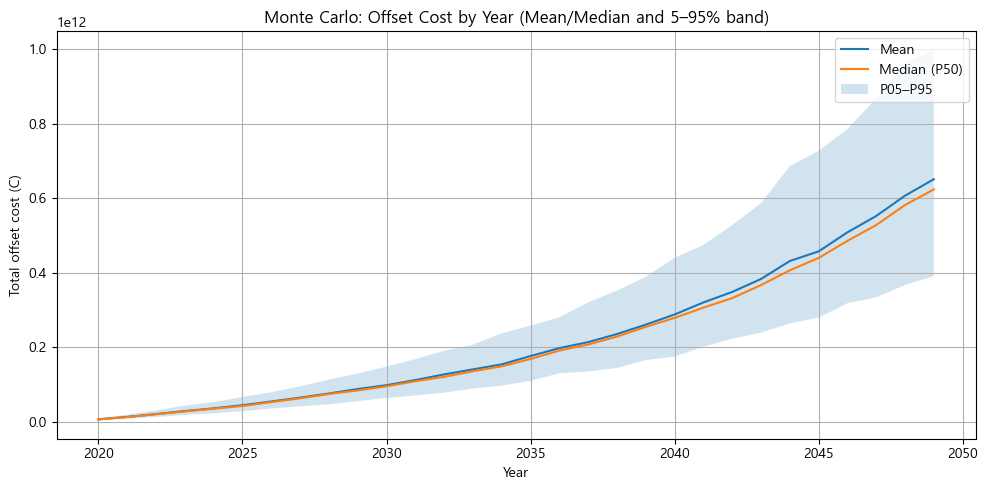

In [143]:
stats = (mc.groupby("year")["C_t"]
           .agg(mean="mean",
                p05=lambda x: x.quantile(0.05),
                p50=lambda x: x.quantile(0.50),
                p95=lambda x: x.quantile(0.95))
           .reset_index())
plt.figure(figsize=(10, 5))

# 평균/중앙값 라인
plt.plot(stats["year"], stats["mean"], label="Mean")
plt.plot(stats["year"], stats["p50"], label="Median (P50)")

# 5~95% 구간 밴드
plt.fill_between(stats["year"], stats["p05"], stats["p95"], alpha=0.2, label="P05–P95")

plt.xlabel("Year")
plt.ylabel("Total offset cost (C)")
plt.title("Monte Carlo: Offset Cost by Year (Mean/Median and 5–95% band)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [155]:
import numpy as np
import pandas as pd

def mc_airline_moments_at_horizon(
    df_2019,
    econ_params,
    carbon_params,
    horizon_year=2030,      # 2019 기준 50년 뒤면 2069
    baseline_year=2019,
    n_sims=1000,
    seed=42,
    O_rule="growth_neutral",
):
    """
    반환: 항공사별 (O_T, C_T)의 mean/var/std + (선택적으로) E_T 등 확장 가능
    """
    rng = np.random.default_rng(seed)
    sim_seeds = rng.integers(0, 2**32 - 1, size=n_sims)

    airlines = df_2019["airline_id"].to_numpy()
    n = len(airlines)

    # Welford 누적 통계용
    count = 0
    mean_O = np.zeros(n, dtype=float)
    M2_O   = np.zeros(n, dtype=float)
    mean_C = np.zeros(n, dtype=float)
    M2_C   = np.zeros(n, dtype=float)

    # (선택) 국적/지역 같이 붙이기용
    meta_cols = [c for c in ["operator_state", "region"] if c in df_2019.columns]
    meta = df_2019[["airline_id"] + meta_cols].copy()

    for sd in sim_seeds:
        # ✅ 1회 run: 전체 기간을 만들 필요 없이 'horizon_year만' 계산하도록 더 최적화할 수도 있지만,
        # 현재 one_run_costs가 years를 받으니 horizon_year 하나만 넣어도 됨.
        sim_df = one_run_costs(
            df_2019=df_2019,
            econ_params=econ_params,
            carbon_params=carbon_params,
            years=[horizon_year],          # ✅ T=50년 시점만 생성
            baseline_year=baseline_year,
            seed=int(sd),
            O_rule=O_rule
        )

        # sim_df는 airline_id 순서가 df_2019와 동일하다는 보장이 없으니 정렬/merge로 맞춤
        sim_df = sim_df[["airline_id", "O_t", "C_t"]].merge(
            meta[["airline_id"]],
            on="airline_id",
            how="right"
        )

        O = sim_df["O_t"].to_numpy()
        C = sim_df["C_t"].to_numpy()

        count += 1

        # Welford 업데이트 (O)
        delta_O = O - mean_O
        mean_O += delta_O / count
        M2_O   += delta_O * (O - mean_O)

        # Welford 업데이트 (C)
        delta_C = C - mean_C
        mean_C += delta_C / count
        M2_C   += delta_C * (C - mean_C)

    # 표본분산 (n_sims>1)
    var_O = M2_O / (count - 1) if count > 1 else np.zeros(n)
    var_C = M2_C / (count - 1) if count > 1 else np.zeros(n)

    out = meta.copy()
    out["year"] = horizon_year
    out["n_sims"] = count

    out["O_mean"] = mean_O
    out["O_var"]  = var_O
    out["O_std"]  = np.sqrt(var_O)

    out["C_mean"] = mean_C
    out["C_var"]  = var_C
    out["C_std"]  = np.sqrt(var_C)

    return out


In [156]:
econ_params = economic_growth["normal"]
carbon_params = carbon_price["high"]

airline_stats_T50 = mc_airline_moments_at_horizon(
    df_2019=df,
    econ_params=econ_params,
    carbon_params=carbon_params,
    horizon_year=2030,   # 2019+50
    n_sims=2000,
    seed=7,
    O_rule="growth_neutral"
)

airline_stats_T50.head()


,airline_id,operator_state,region,year,n_sims,O_mean,O_var,O_std,C_mean,C_var,C_std
0,AL0001,India,APAC,2030,2000,2.909806e+06,1.057053e+13,3.251235e+06,3.534104e+08,1.789753e+17,4.230547e+08
7,AL0002,France,EUR,2030,2000,4.989715e+05,3.013058e+11,5.489133e+05,6.032119e+07,5.014620e+15,7.081398e+07
14,AL0003,Brazil,LAM,2030,2000,8.823646e+05,9.971672e+11,9.985826e+05,1.073720e+08,1.734971e+16,1.317183e+08
21,AL0004,"Korea, Rep.",APAC,2030,2000,1.732002e+06,3.896126e+12,1.973861e+06,2.093937e+08,6.305504e+16,2.511076e+08
28,AL0005,United States,NAM,2030,2000,1.538464e+05,2.780538e+10,1.667495e+05,1.858933e+07,4.478437e+14,2.116232e+07


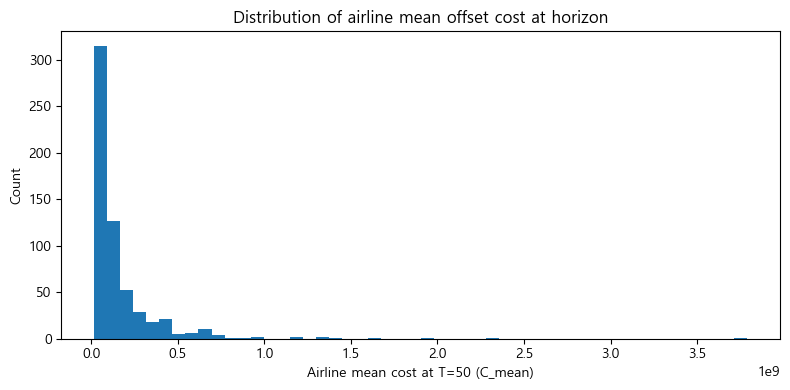

In [157]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(airline_stats_T50["C_mean"], bins=50)
plt.xlabel("Airline mean cost at T=50 (C_mean)")
plt.ylabel("Count")
plt.title("Distribution of airline mean offset cost at horizon")
plt.tight_layout()
plt.show()


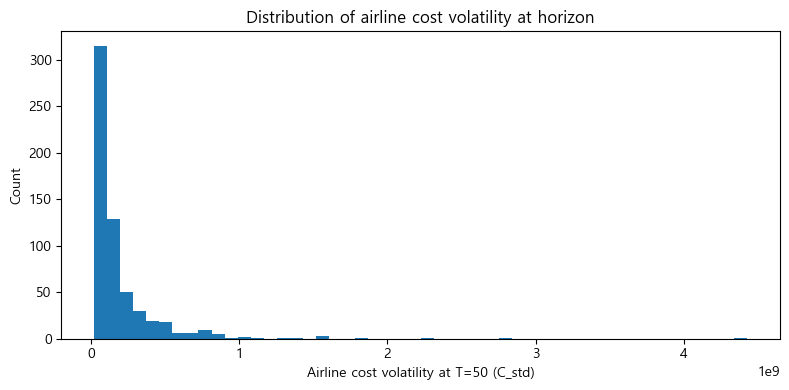

In [158]:
plt.figure(figsize=(8,4))
plt.hist(airline_stats_T50["C_std"], bins=50)
plt.xlabel("Airline cost volatility at T=50 (C_std)")
plt.ylabel("Count")
plt.title("Distribution of airline cost volatility at horizon")
plt.tight_layout()
plt.show()


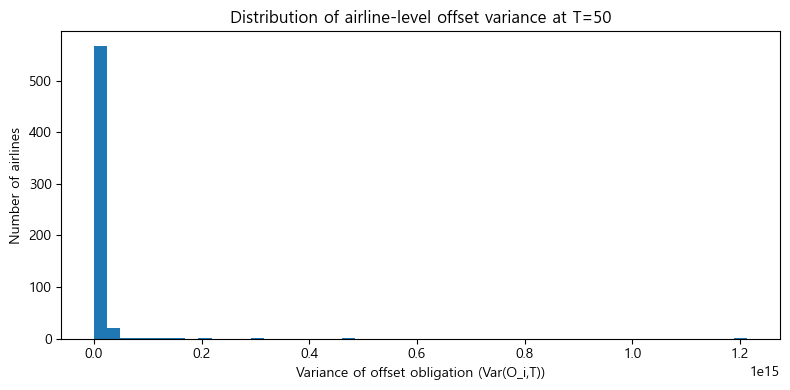

In [159]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(airline_stats_T50["O_var"], bins=50)
plt.xlabel("Variance of offset obligation (Var(O_i,T))")
plt.ylabel("Number of airlines")
plt.title("Distribution of airline-level offset variance at T=50")
plt.tight_layout()
plt.show()


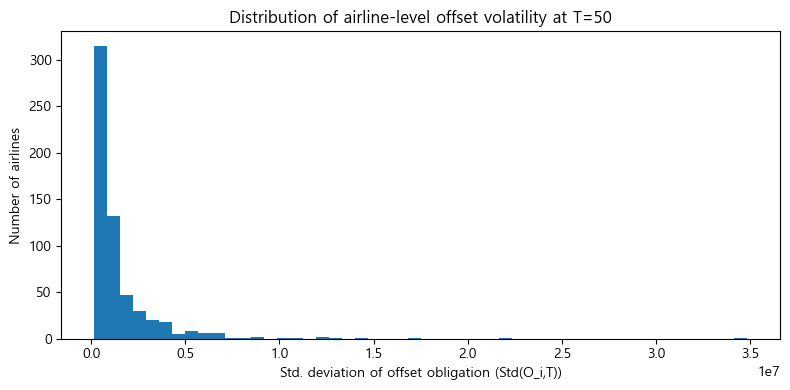

In [160]:
plt.figure(figsize=(8, 4))
plt.hist(airline_stats_T50["O_std"], bins=50)
plt.xlabel("Std. deviation of offset obligation (Std(O_i,T))")
plt.ylabel("Number of airlines")
plt.title("Distribution of airline-level offset volatility at T=50")
plt.tight_layout()
plt.show()


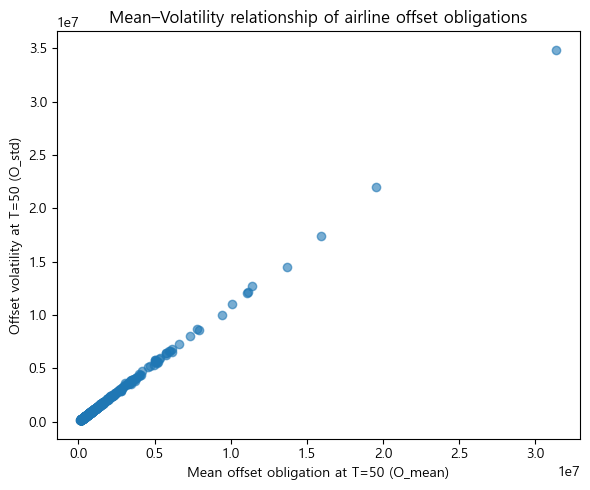

In [161]:
plt.figure(figsize=(6, 5))
plt.scatter(
    airline_stats_T50["O_mean"],
    airline_stats_T50["O_std"],
    alpha=0.6
)
plt.xlabel("Mean offset obligation at T=50 (O_mean)")
plt.ylabel("Offset volatility at T=50 (O_std)")
plt.title("Mean–Volatility relationship of airline offset obligations")
plt.tight_layout()
plt.show()


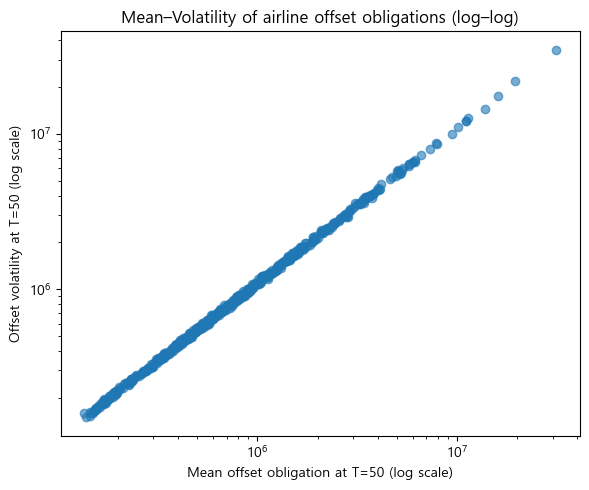

In [162]:
plt.figure(figsize=(6, 5))
plt.scatter(
    airline_stats_T50["O_mean"],
    airline_stats_T50["O_std"],
    alpha=0.6
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Mean offset obligation at T=50 (log scale)")
plt.ylabel("Offset volatility at T=50 (log scale)")
plt.title("Mean–Volatility of airline offset obligations (log–log)")
plt.tight_layout()
plt.show()


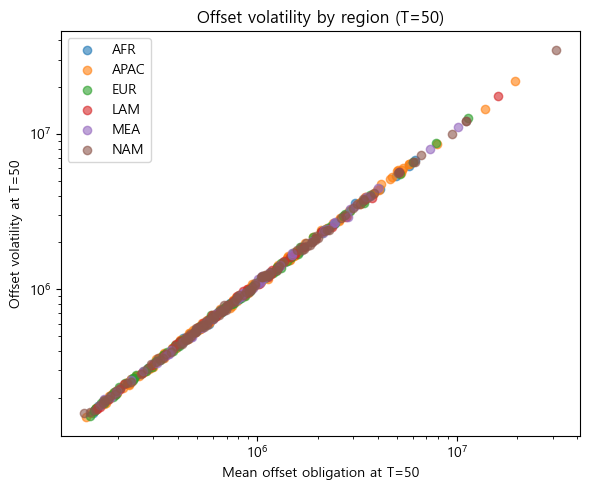

In [163]:
plt.figure(figsize=(6, 5))

for region, g in airline_stats_T50.groupby("region"):
    plt.scatter(g["O_mean"], g["O_std"], label=region, alpha=0.6)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Mean offset obligation at T=50")
plt.ylabel("Offset volatility at T=50")
plt.title("Offset volatility by region (T=50)")
plt.legend()
plt.tight_layout()
plt.show()


# 그룹과 개별 비교

In [164]:
import numpy as np

solo_std = airline_stats_T50["O_std"]

print("Solo (individual) volatility range:")
print(f"min: {solo_std.min():,.0f}")
print(f"max: {solo_std.max():,.0f}")
print(f"median: {np.median(solo_std):,.0f}")


Solo (individual) volatility range:
min: 149,006
max: 34,839,047
median: 784,833


In [165]:
group_stats = (
    airline_stats_T50
    .groupby("region")
    .agg(
        O_mean_group=("O_mean", "sum"),
        O_var_group=("O_var", "sum")   # 공분산 무시한 보수적 상한
    )
    .reset_index()
)

group_stats["O_std_group"] = np.sqrt(group_stats["O_var_group"])


In [166]:
group_std = group_stats["O_std_group"]

print("Group-based volatility range:")
print(f"min: {group_std.min():,.0f}")
print(f"max: {group_std.max():,.0f}")
print(f"median: {np.median(group_std):,.0f}")


Group-based volatility range:
min: 13,297,346
max: 45,215,057
median: 21,767,504


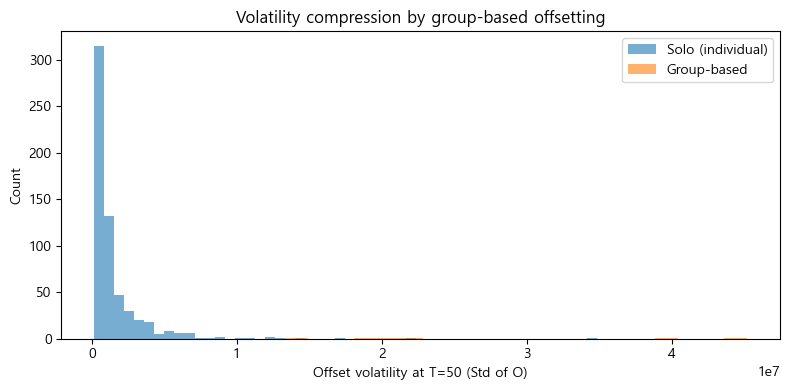

In [167]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(solo_std, bins=50, alpha=0.6, label="Solo (individual)")
plt.hist(group_std, bins=20, alpha=0.6, label="Group-based")

plt.xlabel("Offset volatility at T=50 (Std of O)")
plt.ylabel("Count")
plt.title("Volatility compression by group-based offsetting")
plt.legend()
plt.tight_layout()
plt.show()


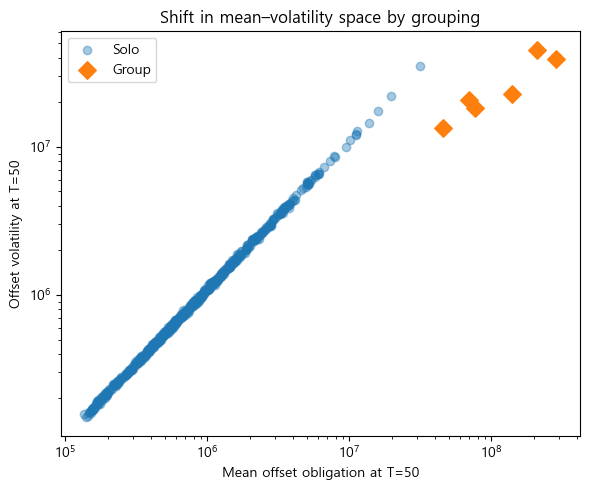

In [168]:
plt.figure(figsize=(6,5))

# 단독
plt.scatter(
    airline_stats_T50["O_mean"],
    airline_stats_T50["O_std"],
    alpha=0.4,
    label="Solo"
)

# 그룹 (그룹 평균을 x축에 둠)
plt.scatter(
    group_stats["O_mean_group"],
    group_stats["O_std_group"],
    marker="D",
    s=80,
    label="Group"
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Mean offset obligation at T=50")
plt.ylabel("Offset volatility at T=50")
plt.title("Shift in mean–volatility space by grouping")
plt.legend()
plt.tight_layout()
plt.show()


In [169]:
solo_group = (
    airline_stats_T50
    .groupby("region")["O_var"]
    .sum()
    .reset_index(name="var_solo_sum")
)


In [171]:
group_var = group_stats[["region", "O_var_group"]]


In [173]:
vol_compare = solo_group.merge(group_var, on="region")

vol_compare["var_reduction_ratio"] = (
    1 - vol_compare["O_var_group"] / vol_compare["var_solo_sum"]
)


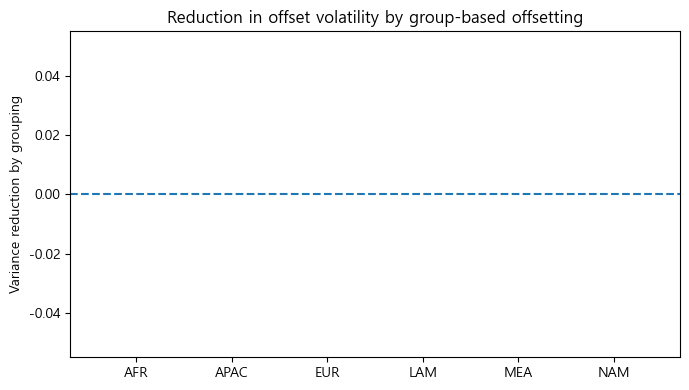

In [174]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.bar(
    vol_compare["region"],
    vol_compare["var_reduction_ratio"]
)

plt.axhline(0, linestyle="--")
plt.ylabel("Variance reduction by grouping")
plt.title("Reduction in offset volatility by group-based offsetting")
plt.tight_layout()
plt.show()


In [175]:
vol_compare["region"],    vol_compare["var_reduction_ratio"]

(0     AFR
 1    APAC
 2     EUR
 3     LAM
 4     MEA
 5     NAM
 Name: region, dtype: object,
 0    0.0
 1    0.0
 2    0.0
 3    0.0
 4    0.0
 5    0.0
 Name: var_reduction_ratio, dtype: float64)

# 재시도

In [182]:
import numpy as np
import pandas as pd

def mc_group_O_at_horizon(
    df_2019,
    econ_params,
    carbon_params,          # ✅ 추가
    horizon_year,
    n_sims=1000,
    seed=42,
    O_rule="growth_neutral",
    baseline_year=2019
):
    rng = np.random.default_rng(seed)
    sim_seeds = rng.integers(0, 2**32 - 1, size=n_sims)

    records = []

    for s, sd in enumerate(sim_seeds, 1):
        sim_df = one_run_costs(
            df_2019=df_2019,
            econ_params=econ_params,
            carbon_params=carbon_params,   # ✅ 추가
            years=[horizon_year],
            baseline_year=baseline_year,
            seed=int(sd),
            O_rule=O_rule
        )

        # region 붙이기
        sim_df = sim_df.merge(
            df_2019[["airline_id", "region"]],
            on="airline_id",
            how="left"
        )

        grp = (
            sim_df
            .groupby("region")["O_t"]
            .sum()
            .reset_index()
        )
        grp["sim"] = s
        records.append(grp)

    return pd.concat(records, ignore_index=True)


In [184]:
group_mc = mc_group_O_at_horizon(
    df_2019=df,
    econ_params=economic_growth["normal"],
    carbon_params=carbon_price["normal"],   # ✅ 추가 (O에는 영향 거의 없지만 필요)
    horizon_year=2069,
    n_sims=1000
)


In [185]:
group_var = (
    group_mc.groupby("region")["O_t"]
            .var()
            .reset_index(name="var_group")
)


In [188]:
solo_var_sum = (
    airline_stats_T50.groupby("region")["O_var"]
                    .sum()
                    .reset_index(name="var_solo_sum")
)

vol_compare = solo_var_sum.merge(group_var, on="region")
vol_compare["var_reduction_ratio"] = 1 - vol_compare["var_group"] / vol_compare["var_solo_sum"]
vol_compare


,region,var_solo_sum,var_group,var_reduction_ratio
0,AFR,1.768194e+14,5.088389e+18,-28776.321387
1,APAC,1.542433e+15,4.827580e+19,-31297.476568
2,EUR,5.183159e+14,1.702481e+19,-32845.395922
3,LAM,4.313287e+14,8.578283e+18,-19887.041454
4,MEA,3.324033e+14,1.088401e+19,-32742.393235
5,NAM,2.044401e+15,6.127190e+19,-29969.580148


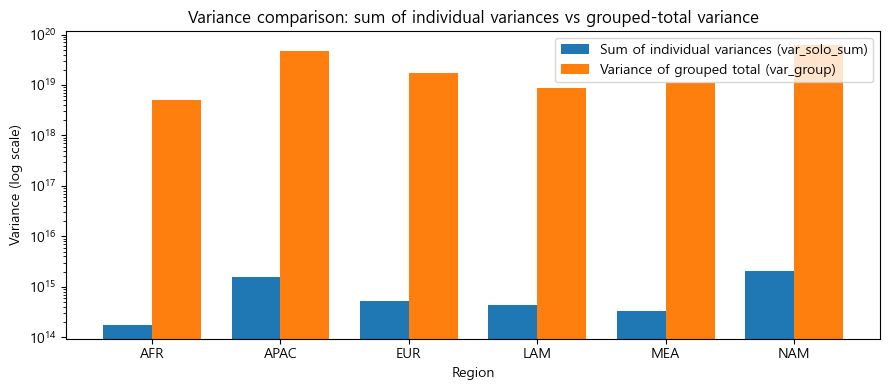

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


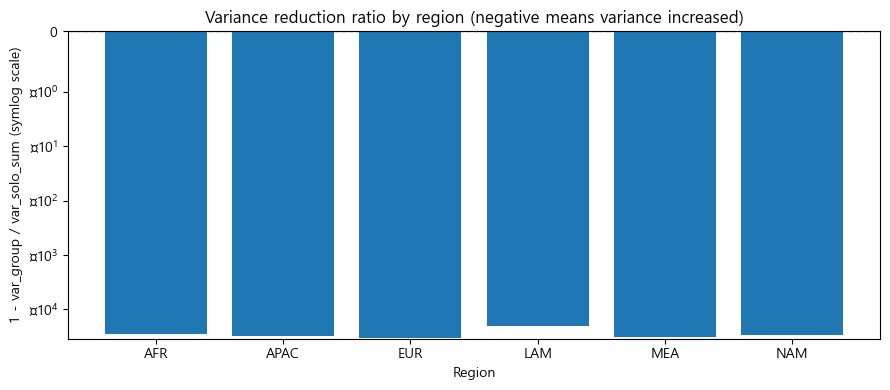

In [189]:
import numpy as np
import matplotlib.pyplot as plt

# region 정렬(원하는 순서 있으면 여기서 고치면 됨)
vc = vol_compare.sort_values("region").copy()

x = np.arange(len(vc))
labels = vc["region"].tolist()

# 1) var_solo_sum vs var_group (로그축)
plt.figure(figsize=(9,4))
w = 0.38
plt.bar(x - w/2, vc["var_solo_sum"], width=w, label="Sum of individual variances (var_solo_sum)")
plt.bar(x + w/2, vc["var_group"],    width=w, label="Variance of grouped total (var_group)")
plt.yscale("log")
plt.xticks(x, labels)
plt.xlabel("Region")
plt.ylabel("Variance (log scale)")
plt.title("Variance comparison: sum of individual variances vs grouped-total variance")
plt.legend()
plt.tight_layout()
plt.show()

# 2) var_reduction_ratio (symlog: 음수/양수 모두 표시)
plt.figure(figsize=(9,4))
plt.bar(x, vc["var_reduction_ratio"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.yscale("symlog", linthresh=1)  # 0 근처는 선형, 멀어지면 로그
plt.xticks(x, labels)
plt.xlabel("Region")
plt.ylabel("1 - var_group / var_solo_sum (symlog scale)")
plt.title("Variance reduction ratio by region (negative means variance increased)")
plt.tight_layout()
plt.show()


In [190]:
import numpy as np
import pandas as pd

# 1) 그룹별: 각 sim에서 O_group(T) 만든 group_mc가 있다고 가정
# group_mc columns: sim, region, O_t

group_cv = (group_mc.groupby("region")["O_t"]
                     .agg(mean="mean", std="std")
                     .assign(cv=lambda d: d["std"]/d["mean"])
                     .reset_index())

# 2) 항공사별: 각 sim에서 O_i(T) 만들어서 airline_mc 필요 (없으면 아래 방법 B로 가자)


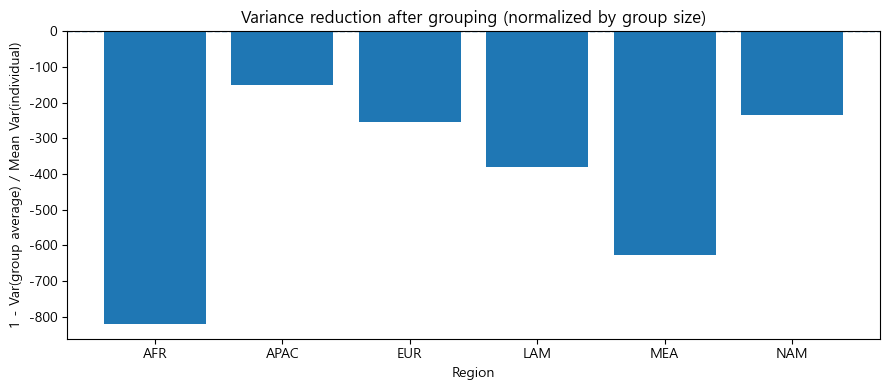

In [193]:
group_size = df.groupby("region")["airline_id"].nunique().reset_index(name="n_g")
group_mc2 = group_mc.merge(group_size, on="region", how="left")
group_mc2["O_avg"] = group_mc2["O_t"] / group_mc2["n_g"]
group_avg_var = (group_mc2.groupby("region")["O_avg"]
                          .var()
                          .reset_index(name="var_group_avg"))
solo_avg_var = (airline_stats_T50.groupby("region")["O_var"]
                              .mean()
                              .reset_index(name="var_solo_avg"))
vc2 = solo_avg_var.merge(group_avg_var, on="region")
vc2["var_reduction_ratio_avg"] = 1 - vc2["var_group_avg"] / vc2["var_solo_avg"]
import matplotlib.pyplot as plt
import numpy as np

vc2 = vc2.sort_values("region")
x = np.arange(len(vc2))

plt.figure(figsize=(9,4))
plt.bar(x, vc2["var_reduction_ratio_avg"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.xticks(x, vc2["region"])
plt.xlabel("Region")
plt.ylabel("1 - Var(group average) / Mean Var(individual)")
plt.title("Variance reduction after grouping (normalized by group size)")
plt.tight_layout()
plt.show()



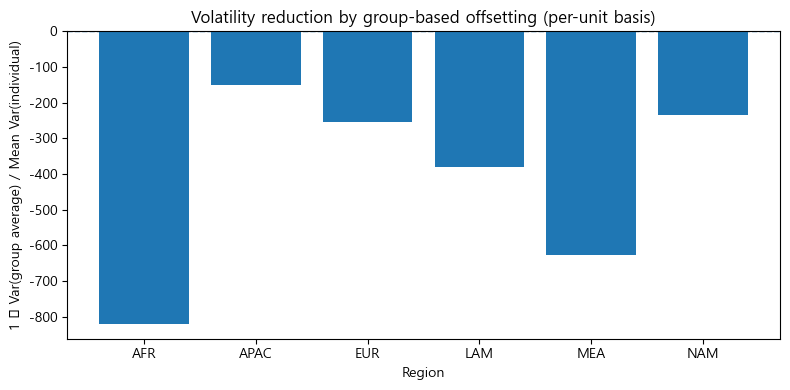

In [194]:
group_size = (
    df.groupby("region")["airline_id"]
      .nunique()
      .reset_index(name="n_g")
)
group_mc_avg = (
    group_mc
    .merge(group_size, on="region", how="left")
)

group_mc_avg["O_avg"] = group_mc_avg["O_t"] / group_mc_avg["n_g"]
group_avg_var = (
    group_mc_avg
    .groupby("region")["O_avg"]
    .var()
    .reset_index(name="var_group_avg")
)
solo_avg_var = (
    airline_stats_T50
    .groupby("region")["O_var"]
    .mean()
    .reset_index(name="var_solo_avg")
)
vc_norm = solo_avg_var.merge(group_avg_var, on="region")

vc_norm["var_reduction_ratio"] = (
    1 - vc_norm["var_group_avg"] / vc_norm["var_solo_avg"]
)

import numpy as np
import matplotlib.pyplot as plt

vc_norm = vc_norm.sort_values("region")
x = np.arange(len(vc_norm))

plt.figure(figsize=(8,4))
plt.bar(x, vc_norm["var_reduction_ratio"])
plt.axhline(0, linestyle="--", linewidth=1)

plt.xticks(x, vc_norm["region"])
plt.xlabel("Region")
plt.ylabel("1 − Var(group average) / Mean Var(individual)")
plt.title("Volatility reduction by group-based offsetting (per-unit basis)")
plt.tight_layout()
plt.show()



## k개의 그룹
전 세계 항공사가 k개의 그룹을 구성했을 때 Var차이
k= 2, 3, 4, 5


In [195]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def build_country_O_matrix(
    df_2019,
    econ_params,
    carbon_params,
    horizon_year=2069,
    n_sims=500,
    seed=42,
    O_rule="growth_neutral",
    baseline_year=2019
):
    rng = np.random.default_rng(seed)
    sim_seeds = rng.integers(0, 2**32 - 1, size=n_sims)

    countries = np.array(sorted(df_2019["operator_state"].unique()))
    c2i = {c: i for i, c in enumerate(countries)}
    O_mat = np.zeros((n_sims, len(countries)), dtype=float)

    for s, sd in enumerate(sim_seeds):
        sim_df = one_run_costs(
            df_2019=df_2019,
            econ_params=econ_params,
            carbon_params=carbon_params,
            years=[horizon_year],
            baseline_year=baseline_year,
            seed=int(sd),
            O_rule=O_rule
        )

        # 국가 정보 붙이기
        sim_df = sim_df.merge(
            df_2019[["airline_id", "operator_state"]],
            on="airline_id",
            how="left"
        )

        # 국가별 상쇄량 합
        by_country = sim_df.groupby("operator_state")["O_t"].sum()

        # 벡터로 채우기
        for c, v in by_country.items():
            O_mat[s, c2i[c]] = v

    return O_mat, countries


In [196]:
def random_partition(indices, K, rng):
    idx = np.array(indices)
    rng.shuffle(idx)
    return np.array_split(idx, K)  # 크기 최대 1 차이로 K개로 쪼갬

def allocate_equal_split(O_mat, groups):
    # O_mat: (n_sims, n_countries)
    alloc = np.zeros_like(O_mat)
    for g in groups:
        g = np.array(g, dtype=int)
        group_total = O_mat[:, g].sum(axis=1)              # (n_sims,)
        alloc[:, g] = group_total[:, None] / len(g)        # 균등분담
    return alloc


In [197]:
def experiment_group_size_effect(
    O_country_mat,
    K_list=(2, 3, 4, 5),
    n_rep=50,
    seed=7
):
    rng = np.random.default_rng(seed)
    n_countries = O_country_mat.shape[1]
    all_idx = np.arange(n_countries)

    records = []
    for K in K_list:
        for r in range(1, n_rep + 1):
            groups = random_partition(all_idx, K, rng)
            alloc = allocate_equal_split(O_country_mat, groups)  # (sims, countries)

            # 국가별 분산 → 국가 평균 분산(요약 지표)
            var_by_country = alloc.var(axis=0, ddof=1)
            mean_var = float(var_by_country.mean())

            # 참고로 평균 그룹 크기
            avg_group_size = n_countries / K

            records.append({
                "K": K,
                "rep": r,
                "avg_group_size": avg_group_size,
                "mean_var_country_burden": mean_var
            })

    return pd.DataFrame(records)


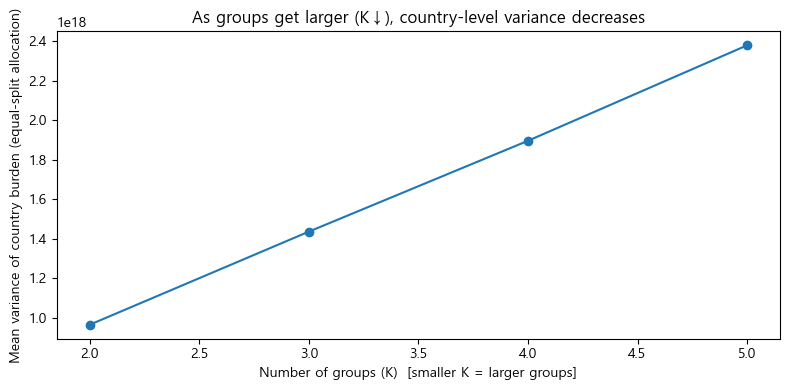

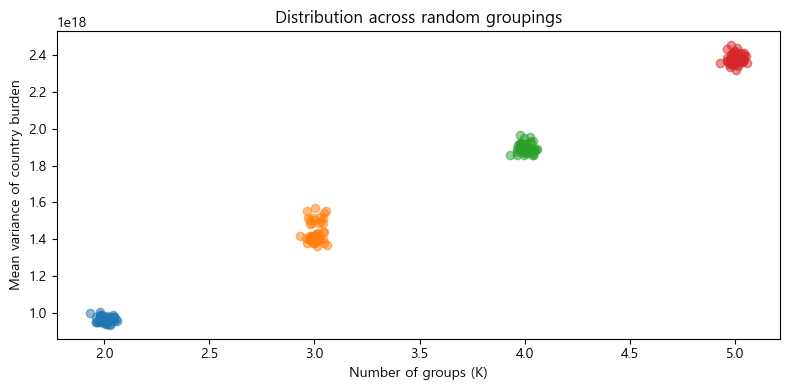

In [199]:
# 1) 국가별 O_T 행렬 생성
O_country_mat, countries = build_country_O_matrix(
    df_2019=df,
    econ_params=economic_growth["normal"],
    carbon_params=carbon_price["normal"],   # O에는 영향 거의 없지만 one_run_costs 때문에 필요
    horizon_year=2069,
    n_sims=500,
    seed=42,
    O_rule="growth_neutral"
)

# 2) 실험
res = experiment_group_size_effect(
    O_country_mat,
    K_list=(2,3,4,5),
    n_rep=50,
    seed=7
)

# 3) K별 평균(반복 평균) 추세선
summary = (res.groupby("K")["mean_var_country_burden"]
             .agg(mean="mean", std="std")
             .reset_index())

plt.figure(figsize=(8,4))
plt.plot(summary["K"], summary["mean"], marker="o")
plt.xlabel("Number of groups (K)  [smaller K = larger groups]")
plt.ylabel("Mean variance of country burden (equal-split allocation)")
plt.title("As groups get larger (K↓), country-level variance decreases")
plt.tight_layout()
plt.show()

# 4) (선택) 반복 분포를 같이 보고 싶으면: K별 산점도(지터)
plt.figure(figsize=(8,4))
for K in sorted(res["K"].unique()):
    y = res.loc[res["K"]==K, "mean_var_country_burden"].to_numpy()
    x = np.full_like(y, fill_value=K, dtype=float) + np.random.default_rng(0).normal(0, 0.03, size=len(y))
    plt.scatter(x, y, alpha=0.5)
plt.xlabel("Number of groups (K)")
plt.ylabel("Mean variance of country burden")
plt.title("Distribution across random groupings")
plt.tight_layout()
plt.show()


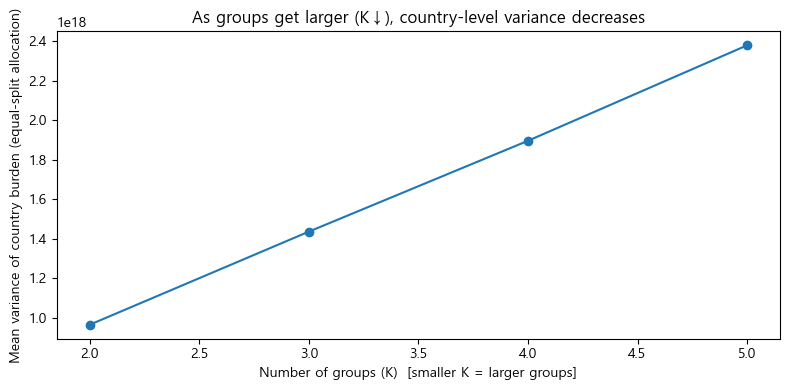

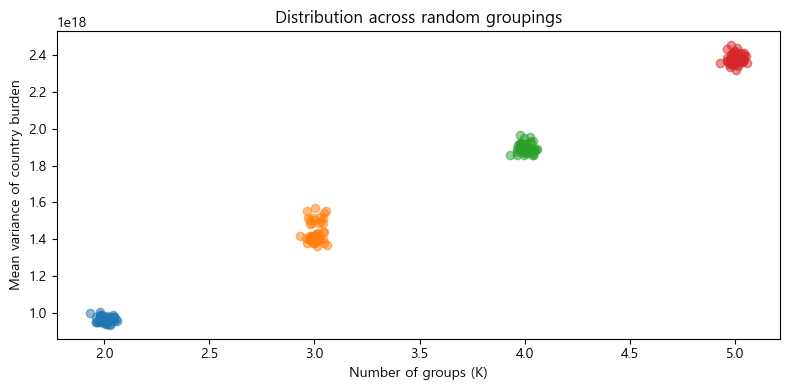

In [221]:
# 1) 국가별 O_T 행렬 생성
O_country_mat, countries = build_country_O_matrix(
    df_2019=df,
    econ_params=economic_growth["normal"],
    carbon_params=carbon_price["normal"],   # O에는 영향 거의 없지만 one_run_costs 때문에 필요
    horizon_year=2069,
    n_sims=500,
    seed=42,
    O_rule="growth_neutral"
)

# 2) 실험
res = experiment_group_size_effect(
    O_country_mat,
    K_list=(2,3,4,5),
    n_rep=50,
    seed=7
)

# 3) K별 평균(반복 평균) 추세선
summary = (res.groupby("K")["mean_var_country_burden"]
             .agg(mean="mean", std="std")
             .reset_index())

plt.figure(figsize=(8,4))
plt.plot(summary["K"], summary["mean"], marker="o")
plt.xlabel("Number of groups (K)  [smaller K = larger groups]")
plt.ylabel("Mean variance of country burden (equal-split allocation)")
plt.title("As groups get larger (K↓), country-level variance decreases")
plt.tight_layout()
plt.show()

# 4) (선택) 반복 분포를 같이 보고 싶으면: K별 산점도(지터)
plt.figure(figsize=(8,4))
for K in sorted(res["K"].unique()):
    y = res.loc[res["K"]==K, "mean_var_country_burden"].to_numpy()
    x = np.full_like(y, fill_value=K, dtype=float) + np.random.default_rng(0).normal(0, 0.03, size=len(y))
    plt.scatter(x, y, alpha=0.5)
plt.xlabel("Number of groups (K)")
plt.ylabel("Mean variance of country burden")
plt.title("Distribution across random groupings")
plt.tight_layout()
plt.show()


## 그룹 구성원의 수를 n으로 한 경우
n이 커짐에 따라 var의 변화는?

한 그룹에 2, 3, 4, 5 개 운항사
        

In [201]:
import numpy as np
import pandas as pd
def random_groups_by_size(indices, k, rng):
    idx = np.array(indices)
    rng.shuffle(idx)
    groups = [idx[i:i+k] for i in range(0, len(idx), k)]
    return groups
def allocate_equal_split(O_mat, groups):
    alloc = np.zeros_like(O_mat)
    for g in groups:
        g = np.array(g, dtype=int)
        group_total = O_mat[:, g].sum(axis=1)
        alloc[:, g] = group_total[:, None] / len(g)
    return alloc
def experiment_group_size_k_effect(
    O_country_mat,
    k_list=(2, 3, 4, 5),
    n_rep=50,
    seed=7
):
    rng = np.random.default_rng(seed)
    n_countries = O_country_mat.shape[1]
    all_idx = np.arange(n_countries)

    records = []
    for k in k_list:
        for r in range(1, n_rep + 1):
            groups = random_groups_by_size(all_idx, k, rng)
            alloc = allocate_equal_split(O_country_mat, groups)

            var_by_country = alloc.var(axis=0, ddof=1)
            mean_var = float(var_by_country.mean())

            records.append({
                "k_group_size": k,
                "rep": r,
                "n_groups": len(groups),
                "mean_var_country_burden": mean_var
            })

    return pd.DataFrame(records)
res_k = experiment_group_size_k_effect(
    O_country_mat,
    k_list=(2,3,4,5),
    n_rep=50,
    seed=7
)


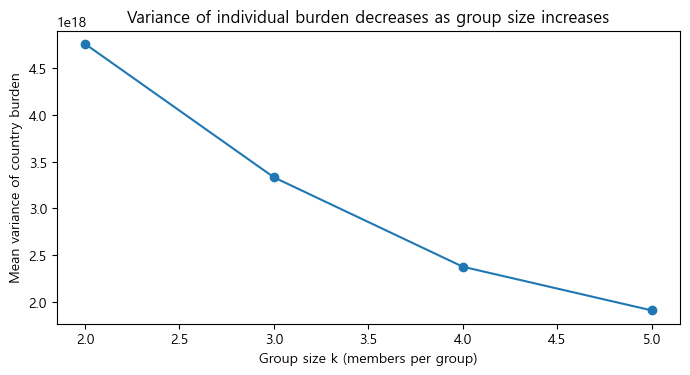

In [205]:
summary_k = (
    res_k.groupby("k_group_size")["mean_var_country_burden"]
         .agg(mean="mean", std="std")
         .reset_index()
)
base = (
    airline_stats_T50
    .groupby("operator_state")["O_var"]
    .mean()
    .mean()
)
summary_k["reduction_ratio_vs_solo"] = 1 - summary_k["mean"] / base
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(
    summary_k["k_group_size"],
    summary_k["mean"],
    marker="o"
)

plt.xlabel("Group size k (members per group)")
plt.ylabel("Mean variance of country burden")
plt.title("Variance of individual burden decreases as group size increases")
plt.tight_layout()
plt.show()



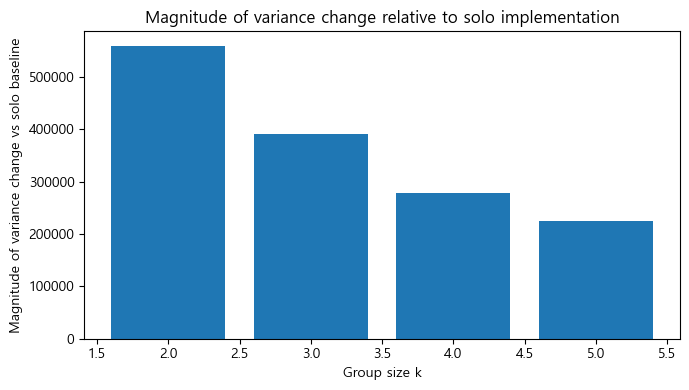

In [207]:
plt.figure(figsize=(7,4))
plt.bar(
    summary_k["k_group_size"],
    -summary_k["reduction_ratio_vs_solo"]
)

plt.xlabel("Group size k")
plt.ylabel("Magnitude of variance change vs solo baseline")
plt.title("Magnitude of variance change relative to solo implementation")
plt.tight_layout()
plt.show()


# k=2 ~ 50


In [208]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 그룹 생성 (k = 그룹당 구성원 수)
def random_groups_by_size(indices, k, rng):
    idx = np.array(indices)
    rng.shuffle(idx)
    return [idx[i:i+k] for i in range(0, len(idx), k)]

# 균등분담
def allocate_equal_split(O_mat, groups):
    alloc = np.zeros_like(O_mat)
    for g in groups:
        g = np.array(g, dtype=int)
        group_total = O_mat[:, g].sum(axis=1)
        alloc[:, g] = group_total[:, None] / len(g)
    return alloc

# k별 분산 실험
def experiment_group_size_k_effect(
    O_country_mat,
    k_min=2,
    k_max=50,
    n_rep=30,
    seed=7
):
    rng = np.random.default_rng(seed)
    n_countries = O_country_mat.shape[1]
    all_idx = np.arange(n_countries)

    records = []
    for k in range(k_min, min(k_max, n_countries) + 1):
        for r in range(1, n_rep + 1):
            groups = random_groups_by_size(all_idx, k, rng)
            alloc = allocate_equal_split(O_country_mat, groups)

            # 국가별 분산 → 평균
            var_by_country = alloc.var(axis=0, ddof=1)
            mean_var = float(var_by_country.mean())

            records.append({
                "k_group_size": k,
                "rep": r,
                "mean_var_country_burden": mean_var
            })

    return pd.DataFrame(records)


In [209]:
res_k = experiment_group_size_k_effect(
    O_country_mat,
    k_min=2,
    k_max=50,
    n_rep=30,   # 30이면 충분히 안정적
    seed=7
)

summary_k = (
    res_k.groupby("k_group_size")["mean_var_country_burden"]
         .agg(mean="mean", std="std")
         .reset_index()
)

summary_k.head()


,k_group_size,mean,std
0,2,4.759986e+18,4.484693e+16
1,3,3.347310e+18,2.020025e+17
2,4,2.393725e+18,3.624012e+16
3,5,1.906204e+18,2.898143e+16
4,6,1.785506e+18,2.641433e+17


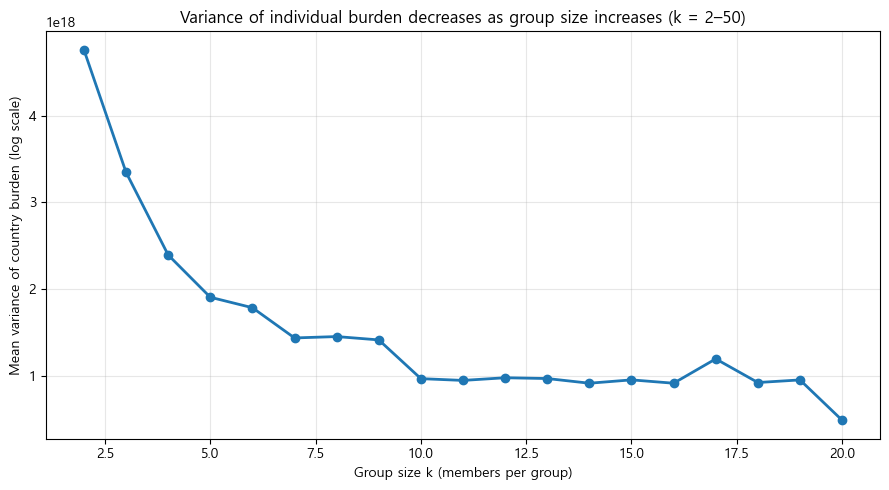

In [214]:
plt.figure(figsize=(9,5))
plt.plot(
    summary_k["k_group_size"],
    summary_k["mean"],
    marker="o",
    linewidth=2
)

# plt.yscale("log")
plt.xlabel("Group size k (members per group)")
plt.ylabel("Mean variance of country burden (log scale)")
plt.title("Variance of individual burden decreases as group size increases (k = 2–50)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


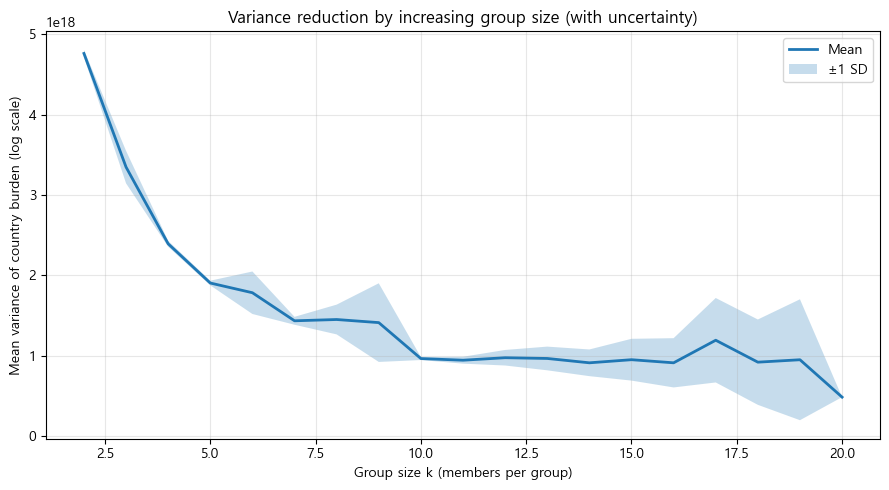

In [215]:
plt.figure(figsize=(9,5))

plt.plot(
    summary_k["k_group_size"],
    summary_k["mean"],
    label="Mean",
    linewidth=2
)

plt.fill_between(
    summary_k["k_group_size"],
    summary_k["mean"] - summary_k["std"],
    summary_k["mean"] + summary_k["std"],
    alpha=0.25,
    label="±1 SD"
)

# plt.yscale("log")
plt.xlabel("Group size k (members per group)")
plt.ylabel("Mean variance of country burden (log scale)")
plt.title("Variance reduction by increasing group size (with uncertainty)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


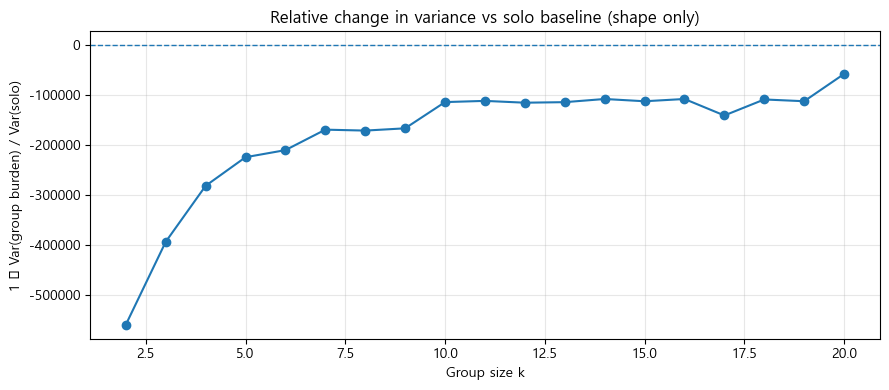

In [213]:
base = (
    airline_stats_T50
    .groupby("operator_state")["O_var"]
    .mean()
    .mean()
)

summary_k["reduction_ratio_vs_solo"] = 1 - summary_k["mean"] / base
plt.figure(figsize=(9,4))
plt.plot(
    summary_k["k_group_size"],
    summary_k["reduction_ratio_vs_solo"],
    marker="o"
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Group size k")
plt.ylabel("1 − Var(group burden) / Var(solo)")
plt.title("Relative change in variance vs solo baseline (shape only)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
